## Armenian Models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/NER
!pip install transformers seqeval[gpu]

Mounted at /content/drive
/content/drive/MyDrive/NER
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=fde514fb3de96eca7792473c88e7ac5ea4f481f4477f682c83a5466c11c7f1f5
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:


import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertConfig, BertForTokenClassification


In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CUDA deterministic (slightly slower)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
DRIVE = device == 'cuda'

if DRIVE:

    train_data = pd.read_csv('/content/drive/MyDrive/NER/train_complete_doctored_V2.csv')
    eval_data = pd.read_csv('/content/drive/MyDrive/NER/eval_ner_doctored_v2.csv')
    test_data = pd.read_csv('/content/drive/MyDrive/NER/test_ner_doctored_v2.csv')
else:
    train_data = pd.read_csv('dataset_formation/data/train_complete_doctored.csv')
    eval_data = pd.read_csv('dataset_formation/data/eval_ner_doctored.csv')
    test_data = pd.read_csv('dataset_formation/data/test_ner_doctored.csv')


SyntaxError: invalid syntax (ipython-input-3901619056.py, line 3)

In [ ]:
labels_to_ids = {k: v for v, k in enumerate(['O','B-INSC','I-INSC'])}
ids_to_labels = {v: k for v, k in enumerate(['O','B-INSC','I-INSC'])}
labels_to_ids

{'O': 0, 'B-INSC': 1, 'I-INSC': 2}

In [ ]:
import pandas as pd

def count_mismatched_rows(df, sentence_col="sentence", labels_col="word_labels"):
    """
    Count rows where the number of words in the sentence
    differs from the number of labels in the word_labels column.

    Returns:
        mismatched_count (int)
        diagnostics_df (pd.DataFrame)
    """

    # Compute word counts (splitting by whitespace)
    df["_word_count"] = df[sentence_col].apply(lambda x: len(str(x).split()))

    # Compute label counts (splitting by comma)
    df["_label_count"] = df[labels_col].apply(lambda x: len(str(x).split(",")))

    # Identify mismatches
    df["_mismatch"] = df["_word_count"] != df["_label_count"]

    # Count mismatched rows
    mismatched_count = df["_mismatch"].sum()

    # Optional: return only mismatch details
    diagnostics_df = df.loc[df["_mismatch"], [
        sentence_col, labels_col, "_word_count", "_label_count"
    ]]

    return mismatched_count, diagnostics_df


In [ ]:
count_mismatched_rows(train_data)

NameError: name 'train_data' is not defined

## Preparing Dataset

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

In [ ]:
from huggingface_hub import login


In [ ]:
MAX_LEN = 128 # might be a bit small
TRAIN_BATCH_SIZE = 32 # 4
VALID_BATCH_SIZE = 32 # 2
EPOCHS = 5 # 1
LEARNING_RATE = 2e-5 # 1e-05 -> For small datasets, you might even try 2e-5 or 3e-5.
MAX_GRAD_NORM = 10

BASE_MODEL_for_aug ="bert-base-multilingual-uncased" # "xlm-roberta-base" #"daviddallakyan2005/armenian-ner" #

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_for_aug)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

In [ ]:
class dataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __getitem__(self, index):
        sentence = self.data.sentence[index].strip().split()
        word_labels = self.data.word_labels[index].split(",")

        encoding = self.tokenizer(
            sentence,
            is_split_into_words=True,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Create aligned labels
        labels = [labels_to_ids[label] for label in word_labels]
        word_ids = encoding.word_ids(batch_index=0)

        # Initialize with -100
        encoded_labels = []
        previous_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                encoded_labels.append(-100)
            elif word_idx != previous_word_idx:
                encoded_labels.append(labels[word_idx])
            else:
                encoded_labels.append(-100)
            previous_word_idx = word_idx

        # Convert everything to tensors
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(encoded_labels, dtype=torch.long)

        return item

    def __len__(self):
        return len(self.data)

In [ ]:
training_set = dataset(train_data.reset_index(), tokenizer, MAX_LEN)
training_set[0]


{'input_ids': tensor([  101, 32020,   402, 15203, 48016, 85760,   374, 32764, 19360, 75694,
         31666, 56485, 52976, 11089,   405, 86980, 13438,   380,   389, 29055,
         83676, 13438,   412,   389, 14836, 26681, 19998, 63259, 32020,   403,
         11392, 80253, 34954, 14836,   374, 14836, 63710, 13445, 12944, 19054,
         50106, 12423,   385, 21916, 27516, 49660,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [ ]:

testing_set = dataset(test_data, tokenizer, MAX_LEN)
validation_set = dataset(eval_data, tokenizer, MAX_LEN)

In [ ]:
train_data.iloc[9]['sentence'], train_data.iloc[9]['word_labels']

('գավթի արևմայան պատի մեջ ագուցված երեսպատման քար հին հուշարձանի շինարարական արձանագրության մաս ներքուստ տող',
 'O,O,O,O,O,O,O,O,O,B-INSC,I-INSC,O,O,O')

In [ ]:
for token, label in zip(tokenizer.convert_ids_to_tokens(training_set[9]["input_ids"]), training_set[9]["labels"]):
  print('{0:10}  {1}'.format(token, label))

[CLS]       -100
գ           0
##ավ        -100
##թի        -100
ա           0
##ր         -100
##և         -100
##մա        -100
##յան       -100
պ           0
##ատի       -100
մեջ         0
ա           0
##գ         -100
##ուց       -100
##ված       -100
ե           0
##ր         -100
##ես        -100
##պ         -100
##ատ        -100
##ման       -100
ք           0
##ար        -100
հին         0
հ           0
##ու        -100
##շ         -100
##ար        -100
##ձ         -100
##անի       -100
շ           1
##ին        -100
##ար        -100
##արական    -100
ա           2
##ր         -100
##ձ         -100
##ան        -100
##ագրության  -100
մ           0
##աս        -100
ն           0
##եր        -100
##ք         -100
##ուստ      -100
տ           0
##ող        -100
[SEP]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD]       -100
[PAD

In [ ]:
train_params = {'batch_size': TRAIN_BATCH_SIZE,
                'shuffle': True,
                'num_workers': 0
                }

test_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': False,
                'num_workers': 0
                }

valid_params = {'batch_size': VALID_BATCH_SIZE,
                'shuffle': False,
                'num_workers': 0
                }

training_loader = DataLoader(training_set, **train_params)
testing_loader = DataLoader(testing_set, **test_params)
validation_loader = DataLoader(validation_set, **test_params)

## Train model

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import torch

def train_one_epoch(epoch, model, training_loader, validation_loader, optimizer, device, ids_to_labels, eval_every=100):
    tr_loss, tr_accuracy = 0, 0
    nb_tr_steps = 0

    train_step_losses = []   # training loss every 100 steps
    eval_step_losses = []    # validation loss every 100 steps

    model.train()
    progress_bar = tqdm(training_loader, desc=f"Epoch {epoch} [Training]", leave=False)

    for idx, batch in enumerate(progress_bar):
        ids = batch['input_ids'].to(device, dtype=torch.long)
        mask = batch['attention_mask'].to(device, dtype=torch.long)
        labels = batch['labels'].to(device, dtype=torch.long)

        outputs = model(input_ids=ids, attention_mask=mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        tr_loss += loss.item()
        nb_tr_steps += 1

        # Accuracy
        flattened_targets = labels.view(-1)
        active_logits = logits.view(-1, model.num_labels)
        flattened_predictions = torch.argmax(active_logits, axis=1)
        active_mask = flattened_targets != -100

        labels_filtered = torch.masked_select(flattened_targets, active_mask)
        preds_filtered = torch.masked_select(flattened_predictions, active_mask)

        tmp_tr_accuracy = accuracy_score(
            labels_filtered.cpu().numpy(),
            preds_filtered.cpu().numpy()
        )
        tr_accuracy += tmp_tr_accuracy

        # Gradient clipping + backward
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record train loss every 100 steps
        if idx % 100 == 0:
            avg_loss = tr_loss / nb_tr_steps
            train_step_losses.append(avg_loss)

            # Run quick evaluation every 100 steps
            model.eval()
            eval_loss, eval_steps = 0, 0
            with torch.no_grad():
                for v_idx, v_batch in enumerate(validation_loader):
                    if v_idx >= 5:  # limit evaluation to 5 batches to save time
                        break
                    v_ids = v_batch['input_ids'].to(device, dtype=torch.long)
                    v_mask = v_batch['attention_mask'].to(device, dtype=torch.long)
                    v_labels = v_batch['labels'].to(device, dtype=torch.long)

                    v_outputs = model(input_ids=v_ids, attention_mask=v_mask, labels=v_labels)
                    eval_loss += v_outputs.loss.item()
                    eval_steps += 1
            model.train()

            eval_step_losses.append(eval_loss / eval_steps)

        # Update tqdm
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{tmp_tr_accuracy:.4f}'
        })

    epoch_loss = tr_loss / nb_tr_steps
    epoch_acc = tr_accuracy / nb_tr_steps

    print(f"\nEpoch {epoch} Summary:")
    print(f"  Training loss: {epoch_loss:.4f}")
    print(f"  Training accuracy: {epoch_acc:.4f}")
    print(f"  Last eval (step-level) loss: {eval_step_losses[-1]:.4f}" if eval_step_losses else "")

    return epoch_loss, epoch_acc, train_step_losses, eval_step_losses

## Eval

In [ ]:

import torch
from tqdm import tqdm

def predict(model, dataloader, device, ids_to_labels):
    """
    Generate predictions and ground truth labels for a token classification model.

    Args:
        model: Trained HuggingFace model (e.g., BertForTokenClassification)
        dataloader: DataLoader providing batches with 'input_ids', 'attention_mask', and 'labels'
        device: torch.device('cuda' or 'cpu')
        ids_to_labels: dict mapping label IDs to label strings

    Returns:

        labels_list: List[List[str]] — true labels per sentence (excluding padding)
        predictions_list: List[List[str]] — predicted labels per sentence (excluding padding)
    """
    model.eval()
    labels_list = []
    predictions_list = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Predicting", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            for i in range(labels.size(0)):
                sentence_labels = labels[i]               # (seq_len,)
                sentence_logits = logits[i]               # (seq_len, num_labels)
                sentence_preds = torch.argmax(sentence_logits, dim=-1)

                # Filter out ignored tokens (-100)
                active_mask = sentence_labels != -100
                filtered_labels = sentence_labels[active_mask]
                filtered_preds = sentence_preds[active_mask]

                labels_list.append([
                    ids_to_labels[id.item()] for id in filtered_labels
                ])
                predictions_list.append([
                    ids_to_labels[id.item()] for id in filtered_preds
                ])

    return labels_list, predictions_list

## BERT Multilingual Augmentation Case Study

In [ ]:
stats=train_data.copy()
stats['output']=~stats['term'].isna()
stats=stats.groupby('file_name')['output'].agg(['sum','count']).reset_index()
stats['rate']=stats['sum']/stats['count']
stats=stats[stats['file_name']!='Divabn_Prak10']
stats.sort_values(by='rate',ascending=True,inplace=True)

In [ ]:
stats['file_name'].values

array(['Divan_Prak2', 'Խոջիվանք', 'Divan_Prak4', 'Divan_Prak3',
       'Divan_Prak5', 'Բուն-Աղվանք-1',
       'ԱՐՑԱԽԻ-ԵՎ-ՍՅՈՒՆԻՔԻ-ՄԵԼԻՔԱԿԱՆ-ԱՊԱՐԱՆՔՆԵՐԸ',
       'ԴԱԴԻ-ՎԱՆՔԻ-ՎԵՐԱԿԱՆԳՆՈՒՄԸ-1997-2011-ԹԹ', 'Divan_Prak8',
       'Divasn_Prak1', 'Divan_Prak9', 'Divan_Prak6', 'Divan_Prak7',
       'ԱԿՈՒՆՔ-ԵՎ-ԿԱԹՆԱՂԲՅՈՒՐ-ԳՅՈՒՂԵՐԻ-ՊԱՏՄԱԿԱՆ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ',
       'ԷՋՄԻԱԾՆԻ ՏԱՊԱՆԱԳՐԵՐ', 'ԱՐՄԱՎԻՐԻ ՄԱՐԶԻ ՎԻՄԱԳՐԱԿԱՆ ԺԱՌԱՆԳ',
       'ԱՆՏԻՊ ՎԻՄԱԳՐԵՐ ԵՐԵՎԱՆԻ ԿԱԹՈՂԻԿԵ ԵԿԵՂԵՑՈՒՑ',
       'ԿՈՎԿԱՍՅԱՆ-ԹԱՆԳԱՐԱՆԻ-ՀԱՅԿԱԿԱՆ-ՀԱՎԱՔԱԾՈՒՆ',
       'ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ'], dtype=object)

In [ ]:
from seqeval.metrics import classification_report

file_names =  ['Divabn_Prak10']+list(stats['file_name'].values)
results = []
df_name="ner_classification_reports_BERT_increment5_increasing_v2.csv"
# Number of files to add in each training increment
INCREMENT_SIZE = 5

# Iterate in chunks of 5 files
for i in range(0, len(file_names), INCREMENT_SIZE):
    model = BertForTokenClassification.from_pretrained(BASE_MODEL_for_aug, num_labels=len(labels_to_ids))
    model.to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=LEARNING_RATE)
    # Select the subset of file names for this iteration
    interest_set = file_names[:i + INCREMENT_SIZE]
    print(interest_set)
    # Prepare current training data
    train_data_curr = train_data[train_data['file_name'].isin(interest_set)].reset_index(drop=True)
    curr_train_dataset = dataset(train_data_curr, tokenizer, MAX_LEN)
    curr_train_loader = DataLoader(curr_train_dataset, **train_params)

    print(f"\n=== Training on {len(interest_set)} files ({i + 1} to {min(i + INCREMENT_SIZE, len(file_names))}) ===")

    # Train for 3 epochs on the current cumulative dataset
    for epoch in range(1, EPOCHS+1):
        train_loss, train_acc, step_train_losses, step_eval_losses = train_one_epoch(
            epoch, model, curr_train_loader, validation_loader, optimizer, device, ids_to_labels, eval_every=100
        )

    # Evaluate on testing data
    labels, predictions = predict(model, testing_loader, device, ids_to_labels)
    curr_metrics = classification_report(labels, predictions, digits=4, output_dict=True)

    # Add metadata
    curr_metrics['trained_files'] = len(interest_set)
    curr_metrics['file_names'] = interest_set.copy()
    curr_metrics['iteration'] = (i // INCREMENT_SIZE) + 1

    results.append(curr_metrics)

# Convert results to DataFrame and save
df_results = pd.DataFrame(results)
df_results.to_csv(df_name, index=False)

print(f"\n✅ Training complete. Results saved to {df_name}")


model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', 'Divan_Prak4', 'Divan_Prak3']

=== Training on 5 files (1 to 5) ===



Epoch 1 Summary:
  Training loss: 0.0104
  Training accuracy: 0.9976
  Last eval (step-level) loss: 0.0170



Epoch 2 Summary:
  Training loss: 0.0024
  Training accuracy: 0.9993
  Last eval (step-level) loss: 0.0127


...


Epoch 2 Summary:
  Training loss: 0.0025
  Training accuracy: 0.9991
  Last eval (step-level) loss: 0.0139



Epoch 3 Summary:
  Training loss: 0.0023
  Training accuracy: 0.9992
  Last eval (step-level) loss: 0.0149



Epoch 4 Summary:
  Training loss: 0.0019
  Training accuracy: 0.9992
  Last eval (step-level) loss: 0.0140



Epoch 5 Summary:
  Training loss: 0.0018
  Training accuracy: 0.9993
  Last eval (step-level) loss: 0.0168



✅ Training complete. Results saved to ner_classification_reports_BERT_increment5_increasing_v2.csv


In [ ]:
metrics=pd.read_csv(df_name)
metrics

,INSC,micro avg,macro avg,weighted avg,trained_files,file_names,iteration
0,"{'precision': np.float64(0.0), 'recall': np.fl...","{'precision': np.float64(0.0), 'recall': np.fl...","{'precision': np.float64(0.0), 'recall': np.fl...","{'precision': np.float64(0.0), 'recall': np.fl...",5,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",1
1,"{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...",10,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",2
2,"{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...",15,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",3
3,"{'precision': np.float64(0.25), 'recall': np.f...","{'precision': np.float64(0.25), 'recall': np.f...","{'precision': np.float64(0.25), 'recall': np.f...","{'precision': np.float64(0.25), 'recall': np.f...",20,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",4


In [ ]:
import re
import pandas as pd
import numpy as np

# load CSV if needed
# metrics = pd.read_csv("ner_progressive_bert_metrics.csv")

# Example: assume metrics is already your DataFrame and has column 'INSC' with stringified dicts
# If some rows are actual dicts, convert them to str for uniform processing:
metrics['INSC_str'] = metrics['INSC'].astype(str)

# Regex builder: matches patterns like:
# 'precision': np.float64(0.5)   OR   "precision": 0.5   OR  'f1-score': 1.2e-3
def extract_metric_from_str(s: str, key: str):
    """
    Extract numeric value for key from string s.
    Returns float or None.
    """
    if not isinstance(s, str) or s.strip().lower() == 'none':
        return None

    # allow single or double quotes around keys, optional spaces, then value which can be:
    #  - np.float64(0.5)
    #  - 0.5
    #  - 1e-3 or 1.23E+03
    # Use a non-greedy approach to avoid grabbing extra commas/braces.
    pattern = rf"""['"]{re.escape(key)}['"]\s*:\s*(?:np\.float64\()\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)?"""
    m = re.search(pattern, s)
    if not m:
        # fallback: look for plain numeric (no np.float64 wrapper)
        pattern2 = rf"""['"]{re.escape(key)}['"]\s*:\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)"""
        m = re.search(pattern2, s)
    if not m:
        return None
    try:
        return float(m.group(1))
    except Exception:
        return None

# Vectorized extraction into new columns
metrics['INSC_precision'] = metrics['INSC_str'].apply(lambda s: extract_metric_from_str(s, 'precision'))
metrics['INSC_recall'] = metrics['INSC_str'].apply(lambda s: extract_metric_from_str(s, 'recall'))
# f1-score key may be 'f1-score' or 'f1_score' depending on source; try both
metrics['INSC_f1'] = metrics['INSC_str'].apply(
    lambda s: extract_metric_from_str(s, 'f1-score')
              if extract_metric_from_str(s, 'f1-score') is not None
              else extract_metric_from_str(s, 'f1_score')
)

# If you prefer NaN for None:
metrics['INSC_precision'] = metrics['INSC_precision'].astype(float)
metrics['INSC_recall'] = metrics['INSC_recall'].astype(float)
metrics['INSC_f1'] = metrics['INSC_f1'].astype(float)

# Drop helper string column if you like
metrics.drop(columns=['INSC_str'], inplace=True)

# Quick check
metrics

,INSC,micro avg,macro avg,weighted avg,trained_files,file_names,iteration,INSC_precision,INSC_recall,INSC_f1
0,"{'precision': np.float64(0.0), 'recall': np.fl...","{'precision': np.float64(0.0), 'recall': np.fl...","{'precision': np.float64(0.0), 'recall': np.fl...","{'precision': np.float64(0.0), 'recall': np.fl...",5,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",1,0.00,0.000000,0.000000
1,"{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...",10,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",2,0.40,0.111111,0.173913
2,"{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...","{'precision': np.float64(0.4), 'recall': np.fl...",15,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",3,0.40,0.111111,0.173913
3,"{'precision': np.float64(0.25), 'recall': np.f...","{'precision': np.float64(0.25), 'recall': np.f...","{'precision': np.float64(0.25), 'recall': np.f...","{'precision': np.float64(0.25), 'recall': np.f...",20,"['Divabn_Prak10', 'Divan_Prak2', 'Խոջիվանք', '...",4,0.25,0.055556,0.090909


In [ ]:
metrics[['trained_files','INSC_precision',	'INSC_recall',	'INSC_f1']]

,trained_files,INSC_precision,INSC_recall,INSC_f1
0,5,0.75,0.500000,0.600000
1,10,0.75,0.166667,0.272727
2,15,0.25,0.055556,0.090909
3,20,0.00,0.000000,0.000000


In [ ]:
model = BertForTokenClassification.from_pretrained(BASE_MODEL_for_aug, num_labels=len(labels_to_ids))
model.load_state_dict(torch.load("/content/drive/MyDrive/NER/progressive_final.pt", map_location=device))
model.to(device)

labels, predictions = predict(model, testing_loader, device, ids_to_labels)
print(classification_report(labels, predictions, digits=4))

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
                                                         

              precision    recall  f1-score   support

        INSC     0.8182    0.5000    0.6207        18

   micro avg     0.8182    0.5000    0.6207        18
   macro avg     0.8182    0.5000    0.6207        18
weighted avg     0.8182    0.5000    0.6207        18



## Statistics

In [ ]:
stats['negative_rate']=1.0-stats['rate']
stats.head()

,file_name,sum,count,rate,negative_rate
19,ՀԱԼԵՊԻ-ԱՐՁԱՆԱԳՐՈՒԹՅՈՒՆՆԵՐԸ,78,78,1.000000,0.000000
18,ԿՈՎԿԱՍՅԱՆ-ԹԱՆԳԱՐԱՆԻ-ՀԱՅԿԱԿԱՆ-ՀԱՎԱՔԱԾՈՒՆ,5,5,1.000000,0.000000
11,ԱՆՏԻՊ ՎԻՄԱԳՐԵՐ ԵՐԵՎԱՆԻ ԿԱԹՈՂԻԿԵ ԵԿԵՂԵՑՈՒՑ,14,140,0.100000,0.900000
12,ԱՐՄԱՎԻՐԻ ՄԱՐԶԻ ՎԻՄԱԳՐԱԿԱՆ ԺԱՌԱՆԳ,3,110,0.027273,0.972727
16,ԷՋՄԻԱԾՆԻ ՏԱՊԱՆԱԳՐԵՐ,5,191,0.026178,0.973822


In [ ]:
metrics['INSC_f1']


,INSC_f1
0,0.600000
1,0.272727
2,0.090909
3,0.000000


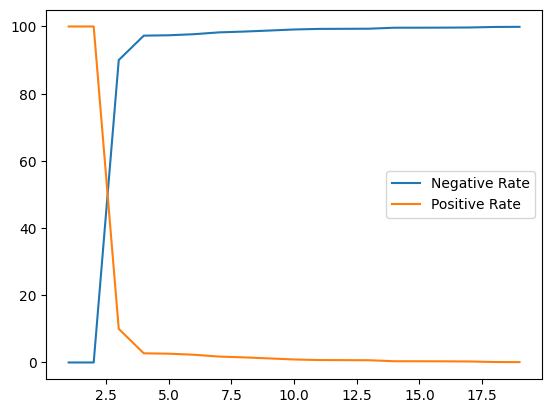

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(list(range(1,len(stats)+1)),stats['negative_rate']*100,label='Negative Rate')
plt.plot(list(range(1,len(stats)+1)),stats['rate']*100,label='Positive Rate')
plt.legend()
plt.show()